# 📘 IMDB Sentiment Analysis with GRU
IT22923288: W G D D Gayashan
Module: Deep Learning Assignment  
Dataset: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

---

### Objective
Perform Sentiment Analysis on IMDB reviews using a GRU deep learning model.


In [14]:
#  Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


[nltk_data] Downloading package stopwords to C:\Users\Dinusanka
[nltk_data]     Gayashan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
#  Load dataset

df = pd.read_csv("../Data/IMDB Dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [16]:
#  Data cleaning

def clean_text(text):
    text = re.sub(r"<.*?>", " ", text)  # remove HTML tags
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = text.lower()
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

df["clean_review"] = df["review"].astype(str).apply(clean_text)
df["label"] = df["sentiment"].map({"positive":1, "negative":0})
df.head(3)


,review,sentiment,clean_review,label
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1


C:\Users\Dinusanka Gayashan\AppData\Local\Temp\ipykernel_9640\220610992.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment", palette="viridis")


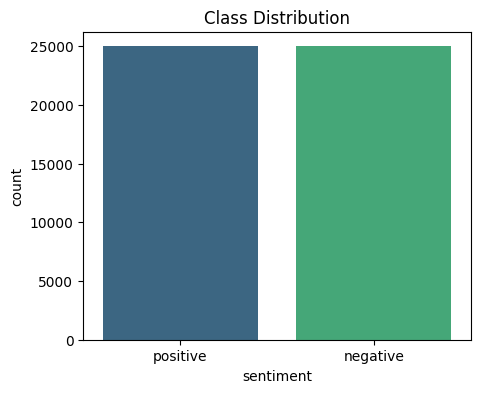

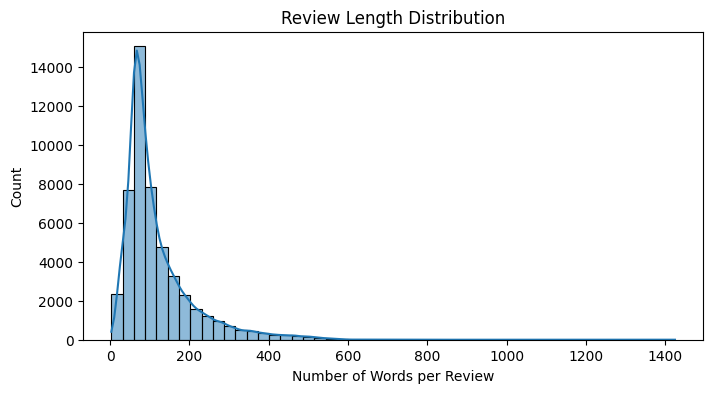

Average review length: 118.84674


In [17]:
# EDA (Exploratory Data Analysis)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="sentiment", palette="viridis")
plt.title("Class Distribution")
plt.show()

# review length distribution
df["review_length"] = df["clean_review"].apply(lambda x: len(x.split()))
plt.figure(figsize=(8,4))
sns.histplot(df["review_length"], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words per Review")
plt.show()

print("Average review length:", df["review_length"].mean())


In [18]:
#  Prepare data for modeling

MAX_VOCAB = 20000
MAX_LEN = 200

X = df["clean_review"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Train shape:", X_train_pad.shape)
print("Test shape:", X_test_pad.shape)


Train shape: (40000, 200)
Test shape: (10000, 200)


In [ ]:
# Save tokenizer & data 

import os, pickle
os.makedirs("../artifacts", exist_ok=True)

np.savez_compressed("../artifacts/data_from_notebook.npz",
                    X_train=X_train_pad, X_test=X_test_pad,
                    y_train=y_train, y_test=y_test)

with open("../artifacts/tokenizer_from_notebook.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Data saved in artifacts/")


Data saved in artifacts/


In [ ]:
from tensorflow.keras import layers, models, optimizers 

def build_gru(max_vocab, embedding_dim=100, max_len=200, gru_units=128, dropout=0.5):
    model = models.Sequential([
        layers.Embedding(input_dim=max_vocab, output_dim=embedding_dim, input_length=max_len),
        layers.SpatialDropout1D(0.2),
        layers.GRU(gru_units, return_sequences=False),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_gru(MAX_VOCAB, 100, MAX_LEN)
model.compile(optimizer=optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# ✅ build before summary
model.build(input_shape=(None, MAX_LEN))
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,096,641 (8.00 MB)

 Trainable params: 2,096,641 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
#  Train GRU Model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
    callbacks=callbacks
)


Epoch 1/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 107s 371ms/step - accuracy: 0.5039 - loss: 0.6953 - val_accuracy: 0.5257 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 101s 358ms/step - accuracy: 0.5271 - loss: 0.6837 - val_accuracy: 0.5255 - val_loss: 0.6912 - learning_rate: 0.0010
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 91s 324ms/step - accuracy: 0.5967 - loss: 0.6147 - val_accuracy: 0.8298 - val_loss: 0.4187 - learning_rate: 0.0010
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 104s 368ms/step - accuracy: 0.8874 - loss: 0.3003 - val_accuracy: 0.8875 - val_loss: 0.2881 - learning_rate: 0.0010
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 100s 354ms/step - accuracy: 0.9432 - loss: 0.1699 - val_accuracy: 0.8882 - val_loss: 0.3123 - learning_rate: 0.0010
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 91s 323ms/step - accuracy: 0.9706 - loss: 0.0991 - val_accuracy: 0.8770 - val_loss: 0.3626 - learning_rate: 0.0010
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 98s 346ms/step - accuracy: 0.9879

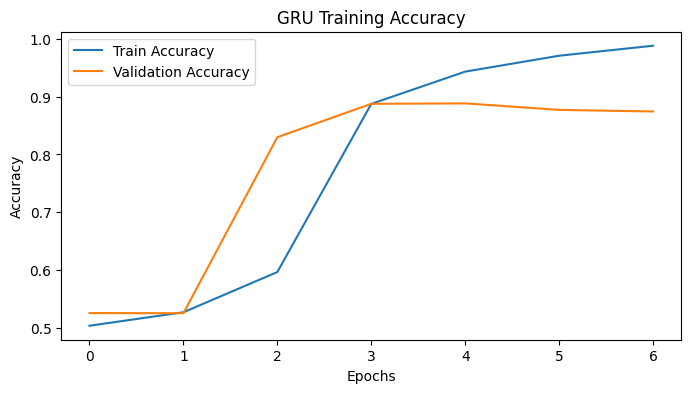

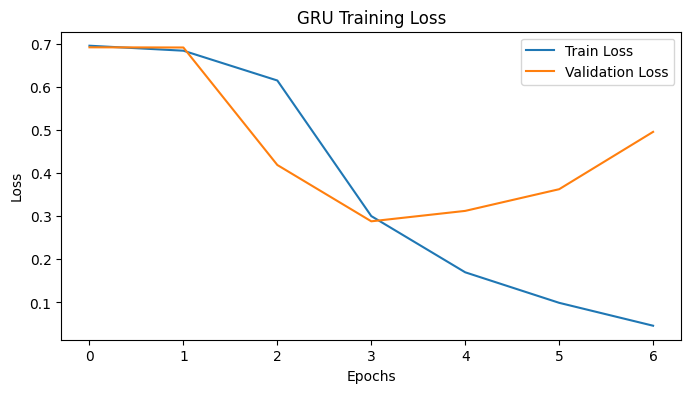

In [23]:
#  Plot training curves

plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("GRU Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("GRU Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
#  Evaluate on Test Set

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

preds = model.predict(X_test_pad).ravel()
pred_labels = (preds >= 0.5).astype(int)

print(classification_report(y_test, pred_labels, digits=4))
print("ROC AUC:", roc_auc_score(y_test, preds))

cm = confusion_matrix(y_test, pred_labels)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Save the trained model

model.save("../artifacts/models/gru_notebook.keras")
print("Model saved successfully ✅")


In [ ]:
# Summary cell

print("✅ GRU Model Training Complete")
print("Test Accuracy:", np.mean(y_test == pred_labels))
print("ROC AUC:", roc_auc_score(y_test, preds))
print("Model and artifacts saved under '../artifacts/'")
